# EJERCICIO TIPO FINAL 5: ENTRENAMIENTO DE RED NURONAL PARA DETERMINAR SI UN PACIENTE SUFRE DE ANEMIA

## FUENTE : [DATOS ABIERTOS](https://www.datosabiertos.gob.pe/dataset/morbilidad-anemia)

In [1]:
!pip install pyjanitor
import janitor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.4/215.4 kB 2.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
DATASET_PATH = 'https://github.com/cesarmayta/datasets/raw/refs/heads/main/TB_ANEMIA.csv'
df_anemia = pd.read_csv(DATASET_PATH,sep = ";")
df_anemia.head(10)

,id_persona,Edad,Tipo_edad,Sexo,id_ubigeo,Fecha_atencion,Diagnostico,Tipo_Dx,id_eess
0,36178991,6,M,F,NaN,20210524,D509,D,2137
1,38986407,2,A,M,1128.0,20211118,D509,D,10836
2,39002414,1,A,F,1128.0,20210417,D509,D,10836
3,39002414,1,A,F,1128.0,20210413,D509,D,10836
4,39002414,3,A,F,1128.0,20220612,D509,D,10836
5,40663149,3,A,F,1542.0,20230613,D509,D,1030
6,39390036,1,A,F,1128.0,20210118,D509,D,10836
7,39390036,1,A,F,1128.0,20210123,D509,D,10836
8,39390036,1,A,F,1128.0,20210518,D509,D,10836
9,39390036,2,A,F,1128.0,20220116,D509,D,10836


# EDA

In [5]:
df_anemia.shape

(1327924, 9)

In [6]:
df_anemia.dtypes

,0
id_persona,int64
Edad,int64
Tipo_edad,object
Sexo,object
id_ubigeo,float64
Fecha_atencion,int64
Diagnostico,object
Tipo_Dx,object
id_eess,int64


# TRATAMIENTO DE NULOS

In [33]:
df_anemia.isnull().sum().sum()

np.int64(10817)

In [34]:
df_anemia.isnull().sum()

,0
id_persona,0
Edad,0
Tipo_edad,0
Sexo,0
id_ubigeo,10817
Fecha_atencion,0
Diagnostico,0
Tipo_Dx,0
id_eess,0


In [35]:
df_anemia.dropna(subset=['id_ubigeo'],inplace=True)
df_anemia.shape

(1317107, 9)

# TRATAMIENTO DE DUPLICADOS

In [36]:
df_anemia.duplicated().sum()

np.int64(19287)

In [37]:
df_anemia[df_anemia.duplicated()]

,id_persona,Edad,Tipo_edad,Sexo,id_ubigeo,Fecha_atencion,Diagnostico,Tipo_Dx,id_eess
16,39347963,1,A,F,1128.0,20210814,D509,D,21206
28,41907576,6,M,F,1209.0,20240316,D509,D,17076
574,39320800,3,A,F,1504.0,20210312,D509,D,87
629,38701922,4,A,M,42.0,20220104,D509,D,5180
660,39320673,4,A,F,42.0,20221029,D509,D,5188
...,...,...,...,...,...,...,...,...,...
1327161,42009830,6,M,M,1453.0,20240507,D509,D,12
1327223,41940907,7,M,M,1000.0,20240613,D509,D,3356
1327377,42037152,6,M,F,1276.0,20240518,D509,D,4404
1327466,42068631,6,M,M,1322.0,20240530,D509,D,5846


In [38]:
df_anemia.drop_duplicates(keep='first',inplace=True)
df_anemia.shape

(1297820, 9)

# ANALIZANDO VARIABLES

## ELIMINAMOS ID_PERSONA

In [39]:
df_anemia.drop(['id_persona'],axis=1,inplace=True)
df_anemia.head(10)

,Edad,Tipo_edad,Sexo,id_ubigeo,Fecha_atencion,Diagnostico,Tipo_Dx,id_eess
1,2,A,M,1128.0,20211118,D509,D,10836
2,1,A,F,1128.0,20210417,D509,D,10836
3,1,A,F,1128.0,20210413,D509,D,10836
4,3,A,F,1128.0,20220612,D509,D,10836
5,3,A,F,1542.0,20230613,D509,D,1030
6,1,A,F,1128.0,20210118,D509,D,10836
7,1,A,F,1128.0,20210123,D509,D,10836
8,1,A,F,1128.0,20210518,D509,D,10836
9,2,A,F,1128.0,20220116,D509,D,10836
10,3,A,F,1597.0,20210529,D509,D,2177


# CONVERTIMOS DATA  DE EDAD A AÑOS

In [40]:
df_anemia.Tipo_edad.value_counts()

,count
Tipo_edad,
A,920953
M,375857
D,1010


In [41]:
df_anemia['edad_total'] = np.where(
    df_anemia['Tipo_edad'] == 'M', df_anemia['Edad'] / 12,
    np.where(df_anemia['Tipo_edad'] == 'D', df_anemia['Edad'] / 365, df_anemia['Edad'])
)
df_anemia[df_anemia['Tipo_edad']=='D'].head(10)

,Edad,Tipo_edad,Sexo,id_ubigeo,Fecha_atencion,Diagnostico,Tipo_Dx,id_eess,edad_total
944,1,D,F,1128.0,20210531,D509,D,10836,0.002740
1418,20,D,M,994.0,20210608,D539,D,3364,0.054795
5144,1,D,F,1317.0,20210426,D509,D,5509,0.002740
6928,1,D,M,1484.0,20220407,D509,D,143,0.002740
6987,18,D,M,1458.0,20210702,D509,D,64,0.049315
6991,24,D,M,1473.0,20210706,D509,D,105,0.065753
7157,1,D,F,1322.0,20210811,D509,D,6129,0.002740
7613,6,D,F,1464.0,20210213,D509,D,212,0.016438
7862,1,D,M,1460.0,20210805,D509,D,16,0.002740
7881,1,D,F,1463.0,20210807,D509,D,30,0.002740


# ANALIZAMOS ID_UBIGEO

In [16]:
df_anemia['id_ubigeo'].value_counts()

,count
id_ubigeo,
1312.0,33487
1283.0,20689
1290.0,13846
1863.0,13049
1323.0,13029
...,...
1842.0,1
320.0,1
1723.0,1


In [42]:
PATH_UBIGEOS = 'https://github.com/cesarmayta/datasets/raw/refs/heads/main/TB_UBIGEOS.csv'
df_ubigeos = pd.read_csv(PATH_UBIGEOS,sep=';')
df_ubigeos.head(10)

,id_ubigeo,ubigeo_reniec,ubigeo_inei,departamento_inei,departamento,provincia_inei,provincia,distrito,region,macroregion_inei,macroregion_minsa,iso_3166_2,fips,superficie,altitud,latitud,longitud,Frontera
0,1,10101.0,10101,1,AMAZONAS,101,CHACHAPOYAS,CHACHAPOYAS,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,154.0,2338.0,-6.2294,-77.8728,NO
1,2,10102.0,10102,1,AMAZONAS,101,CHACHAPOYAS,ASUNCION,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,26.0,2823.0,-6.0325,-77.7108,NO
2,3,10103.0,10103,1,AMAZONAS,101,CHACHAPOYAS,BALSAS,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,357.0,859.0,-6.8358,-78.0197,NO
3,4,10104.0,10104,1,AMAZONAS,101,CHACHAPOYAS,CHETO,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,57.0,2143.0,-6.2556,-77.7008,NO
4,5,10105.0,10105,1,AMAZONAS,101,CHACHAPOYAS,CHILIQUIN,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,143.0,2677.0,-6.0783,-77.7375,NO
5,6,10106.0,10106,1,AMAZONAS,101,CHACHAPOYAS,CHUQUIBAMBA,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,279.0,2803.0,-6.9350,-77.8542,NO
6,7,10107.0,10107,1,AMAZONAS,101,CHACHAPOYAS,GRANADA,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,181.0,3041.0,-6.1064,-77.6286,NO
7,8,10108.0,10108,1,AMAZONAS,101,CHACHAPOYAS,HUANCAS,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,49.0,2591.0,-6.1736,-77.8644,NO
8,9,10109.0,10109,1,AMAZONAS,101,CHACHAPOYAS,LA JALCA,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,380.0,2869.0,-6.4847,-77.8150,NO
9,10,10110.0,10110,1,AMAZONAS,101,CHACHAPOYAS,LEIMEBAMBA,AMAZONAS,ORIENTE,MACROREGION ORIENTE,PE-AMA,1,373.0,2226.0,-6.7075,-77.8039,NO


In [43]:
df_anemia_ubigeo = df_ubigeos[['id_ubigeo','departamento']].copy()
df_anemia_ubigeo.head()

,id_ubigeo,departamento
0,1,AMAZONAS
1,2,AMAZONAS
2,3,AMAZONAS
3,4,AMAZONAS
4,5,AMAZONAS


In [44]:
df_anemia = df_anemia.merge(df_anemia_ubigeo,on='id_ubigeo',how='left')
df_anemia.head(10)

,Edad,Tipo_edad,Sexo,id_ubigeo,Fecha_atencion,Diagnostico,Tipo_Dx,id_eess,edad_total,departamento
0,2,A,M,1128.0,20211118,D509,D,10836,2.0,JUNIN
1,1,A,F,1128.0,20210417,D509,D,10836,1.0,JUNIN
2,1,A,F,1128.0,20210413,D509,D,10836,1.0,JUNIN
3,3,A,F,1128.0,20220612,D509,D,10836,3.0,JUNIN
4,3,A,F,1542.0,20230613,D509,D,1030,3.0,PASCO
5,1,A,F,1128.0,20210118,D509,D,10836,1.0,JUNIN
6,1,A,F,1128.0,20210123,D509,D,10836,1.0,JUNIN
7,1,A,F,1128.0,20210518,D509,D,10836,1.0,JUNIN
8,2,A,F,1128.0,20220116,D509,D,10836,2.0,JUNIN
9,3,A,F,1597.0,20210529,D509,D,2177,3.0,PIURA


In [45]:
df_anemia['cie10'] = np.where(df_anemia['Diagnostico'].str.startswith(('D50','D53','D64')),1,0)

In [46]:
df_anemia.head(3)

,Edad,Tipo_edad,Sexo,id_ubigeo,Fecha_atencion,Diagnostico,Tipo_Dx,id_eess,edad_total,departamento,cie10
0,2,A,M,1128.0,20211118,D509,D,10836,2.0,JUNIN,1
1,1,A,F,1128.0,20210417,D509,D,10836,1.0,JUNIN,1
2,1,A,F,1128.0,20210413,D509,D,10836,1.0,JUNIN,1


In [47]:
df_anemia['Fecha_atencion'] = df_anemia['Fecha_atencion'].astype(str)
df_anemia['mes'] = df_anemia['Fecha_atencion'].str[4:6]
df_anemia.head(1)

,Edad,Tipo_edad,Sexo,id_ubigeo,Fecha_atencion,Diagnostico,Tipo_Dx,id_eess,edad_total,departamento,cie10,mes
0,2,A,M,1128.0,20211118,D509,D,10836,2.0,JUNIN,1,11


In [48]:
df_anemia_processed = df_anemia[['mes','Sexo','departamento','edad_total','cie10']].copy()
df_anemia_processed.rename(columns={'Sexo':'sexo','departamento':'dpto','edad_total':'edad','cie10':'anemia'},inplace=True)
df_anemia_processed.head()

,mes,sexo,dpto,edad,anemia
0,11,M,JUNIN,2.0,1
1,04,F,JUNIN,1.0,1
2,04,F,JUNIN,1.0,1
3,06,F,JUNIN,3.0,1
4,06,F,PASCO,3.0,1


In [49]:
df_anemia_processed.dtypes

,0
mes,object
sexo,object
dpto,object
edad,float64
anemia,int64


In [50]:
df_anemia_processed["sexo"] = df_anemia_processed["sexo"].map({"M": 1, "F": 0})
df_anemia_processed

,mes,sexo,dpto,edad,anemia
0,11,1,JUNIN,2.0,1
1,04,0,JUNIN,1.0,1
2,04,0,JUNIN,1.0,1
3,06,0,JUNIN,3.0,1
4,06,0,PASCO,3.0,1
...,...,...,...,...,...
1297815,08,0,LIMA,1.0,0
1297816,03,1,LIMA,0.5,1
1297817,03,0,LIMA,11.0,0
1297818,04,0,LIMA,5.0,1


In [51]:
df_anemia_processed

,mes,sexo,dpto,edad,anemia
0,11,1,JUNIN,2.0,1
1,04,0,JUNIN,1.0,1
2,04,0,JUNIN,1.0,1
3,06,0,JUNIN,3.0,1
4,06,0,PASCO,3.0,1
...,...,...,...,...,...
1297815,08,0,LIMA,1.0,0
1297816,03,1,LIMA,0.5,1
1297817,03,0,LIMA,11.0,0
1297818,04,0,LIMA,5.0,1


In [52]:
df_anemia = df_anemia_processed[['sexo','edad','anemia']].copy()
df_anemia

,sexo,edad,anemia
0,1,2.0,1
1,0,1.0,1
2,0,1.0,1
3,0,3.0,1
4,0,3.0,1
...,...,...,...
1297815,0,1.0,0
1297816,1,0.5,1
1297817,0,11.0,0
1297818,0,5.0,1


# GUARDAMOS EL DATASET

In [53]:
df_anemia.to_csv('anemia.csv',index=False)

In [54]:
df = pd.read_csv('/content/anemia.csv')
df

,sexo,edad,anemia
0,1,2.0,1
1,0,1.0,1
2,0,1.0,1
3,0,3.0,1
4,0,3.0,1
...,...,...,...
1297815,0,1.0,0
1297816,1,0.5,1
1297817,0,11.0,0
1297818,0,5.0,1


# PREPARACION DE LOS DATOS PARA ENTRENAMIENTO CON REDES NEURONALES

## ESCALAMIENTO DE VARIABLES

In [55]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled)
df_scaled.columns = df.columns
df_scaled

,sexo,edad,anemia
0,1.0,0.181614,1.0
1,0.0,0.090683,1.0
2,0.0,0.090683,1.0
3,0.0,0.272546,1.0
4,0.0,0.272546,1.0
...,...,...,...
1297815,0.0,0.090683,0.0
1297816,1.0,0.045217,1.0
1297817,0.0,1.000000,0.0
1297818,0.0,0.454410,1.0


## DIVIDIMOS DATASET EN ENTRENAMIENTO Y PRUEBA

In [56]:
from sklearn.model_selection import train_test_split
X = df_scaled.drop(columns = ['anemia'])
y = df_scaled[['anemia']]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,random_state=42)

## CREAMOS NUESTRA RED NEURONAL

In [58]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout

red = Sequential()
entrada = Dense(units=2,activation='relu')
oculta1 = Dense(units=100,activation='relu')
oculta2 = Dense(units=100,activation='relu')
salida = Dense(1,activation='sigmoid')

red.add(entrada)
red.add(oculta1)
red.add(Dropout(0.5))
red.add(oculta2)
red.add(salida)

## CONFIGURAMOS LA RED NEURONAL

In [59]:
red.compile(
    optimizer= tf.keras.optimizers.RMSprop(learning_rate=0.01),
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

# ENTRENAMOS LA RED NEURONAL

In [65]:
red1 = red.fit(X_train,y_train,batch_size=100,epochs=50,validation_data=(X_test, y_test))

Epoch 1/50
9085/9085 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.9977 - loss: 0.0164 - val_accuracy: 0.9979 - val_loss: 0.0155
Epoch 2/50
9085/9085 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.9977 - loss: 0.0163 - val_accuracy: 0.9979 - val_loss: 0.0153
Epoch 3/50
9085/9085 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.9977 - loss: 0.0163 - val_accuracy: 0.9979 - val_loss: 0.0150
Epoch 4/50
9085/9085 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.9978 - loss: 0.0157 - val_accuracy: 0.9979 - val_loss: 0.0150
Epoch 5/50
9085/9085 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.9979 - loss: 0.0155 - val_accuracy: 0.9979 - val_loss: 0.0150
Epoch 6/50
9085/9085 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.9978 - loss: 0.0161 - val_accuracy: 0.9979 - val_loss: 0.0154
Epoch 7/50
9085/9085 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - accuracy: 0.9977 - loss: 0.0162 - val_accuracy: 0.9979 - val_loss: 0.0158
Epoch 8/50
9085/9085 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.9978 - loss: 0

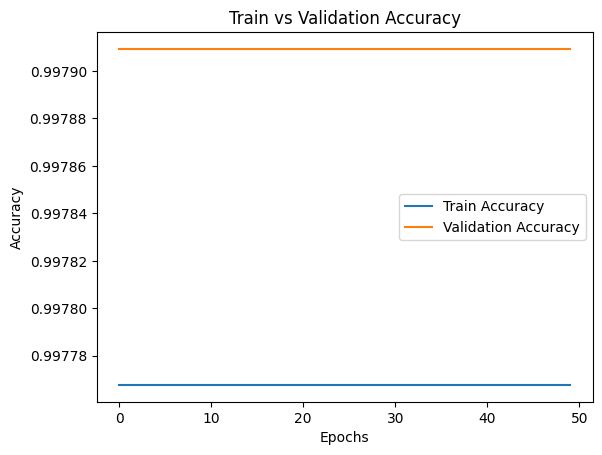

In [66]:
# Obtener los valores de accuracy y validation accuracy
train_acc = red1.history['accuracy']
val_acc = red1.history['val_accuracy']

# Crear el gráfico
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Train vs Validation Accuracy')
plt.show()

12168/12168 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step
el score de validacion y predicción es 0.997909314594217


<Figure size 1100x1100 with 0 Axes>

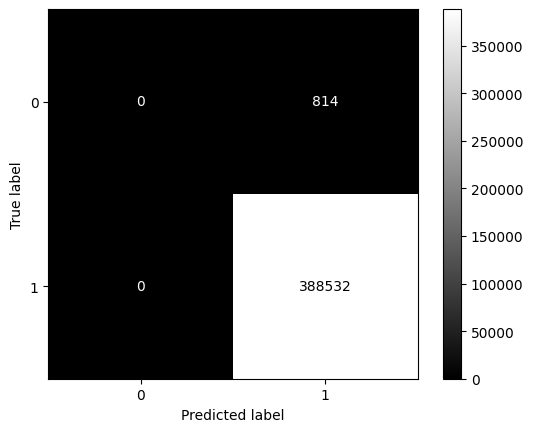

In [67]:
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay
y_pred = red.predict(X_test)
y_pred = np.round(y_pred)

score = accuracy_score(y_test,y_pred)
print(f'el score de validacion y predicción es {score}')

fig = plt.figure(figsize=(11,11))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap='gray')
plt.show()